# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Data/yulu_bike_sharing_dataset.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive



---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [4]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

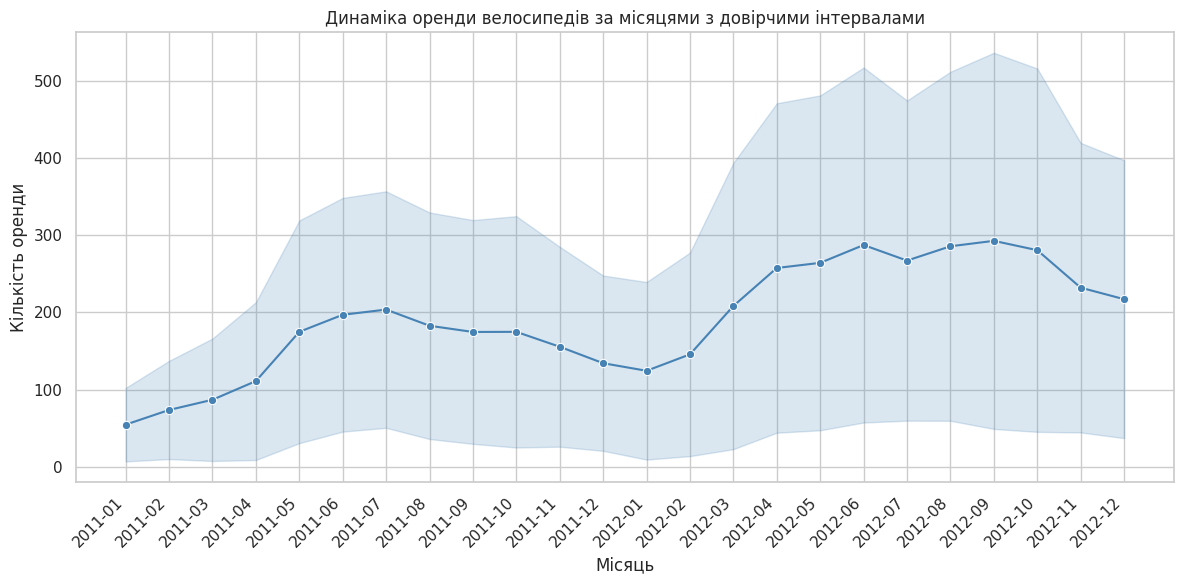

In [10]:
# Розраховуємо середню кількість оренд по кожному місяцю
# groupby групує всі рядки з однаковим місяць_рік разом
monthly = df.groupby('month_year')['count'].mean().reset_index()

# Будуємо графік
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df,
    x='month_year',    # вісь X — місяць-рік (2011-01, 2011-02...)
    y='count',         # вісь Y — кількість оренд
    errorbar='sd',     # затінена зона = ±1 стандартне відхилення
    marker='o',        # крапка на кожному місяці
    color='steelblue'
)

# errorbar='sd' сам розраховує середнє + відхилення,

plt.title('Динаміка оренди велосипедів за місяцями з довірчими інтервалами')
plt.xlabel('Місяць')
plt.ylabel('Кількість оренди')
plt.xticks(rotation=45, ha='right') # повертаємо підписи щоб не перекривались
plt.tight_layout()
plt.show()

Найбільша невизначеність — у літні місяці (червень-серпень), де затінена зона найширша. Це означає, що кількість оренд у ці місяці дуже варіюється від дня до дня.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

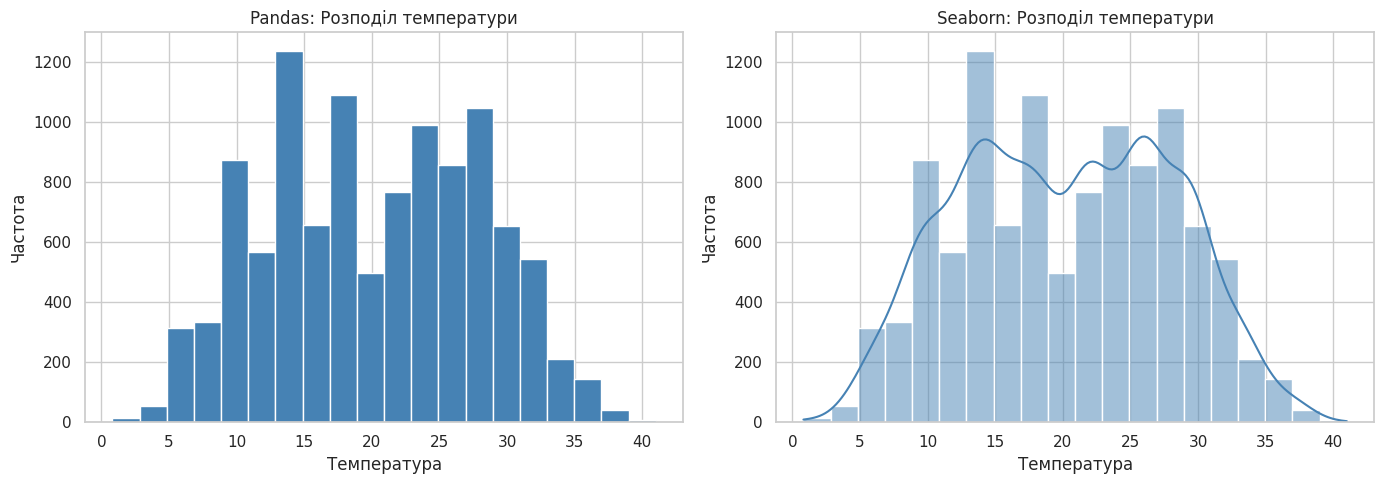

In [12]:
# Створюємо 2 графіки на 1 фігурі поруч
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Спосіб 1: Pandas ---
df['temp'].plot(
    kind='hist',
    bins=20,
    ax=axes[0],
    color='steelblue',
    edgecolor='white',
    title='Pandas: Розподіл температури'
)
axes[0].set_xlabel('Температура')
axes[0].set_ylabel('Частота')

# --- Спосіб 2: Seaborn ---
sns.histplot(
    data=df,
    x='temp',
    bins=20,
    kde=True,       # додаткова лінія щільності (KDE)
    ax=axes[1],
    color='steelblue'
)
axes[1].set_title('Seaborn: Розподіл температури')
axes[1].set_xlabel('Температура')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

1. Візуальна різниця між Pandas та Seaborn:
Pandas будує просту гістограму — лише стовпці. Seaborn додає KDE-криву (Kernel Density Estimation) — плавну лінію поверх стовпців, яка показує загальну форму розподілу.
2. Що таке KDE-лінія:
KDE (Kernel Density Estimation) — це крива згладженої щільності розподілу. Вона показує, де зосереджено більшість значень, без “зубчастості” стовпців. Своїми словами: це плавна версія гістограми, яка краще показує загальну тенденцію даних.

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

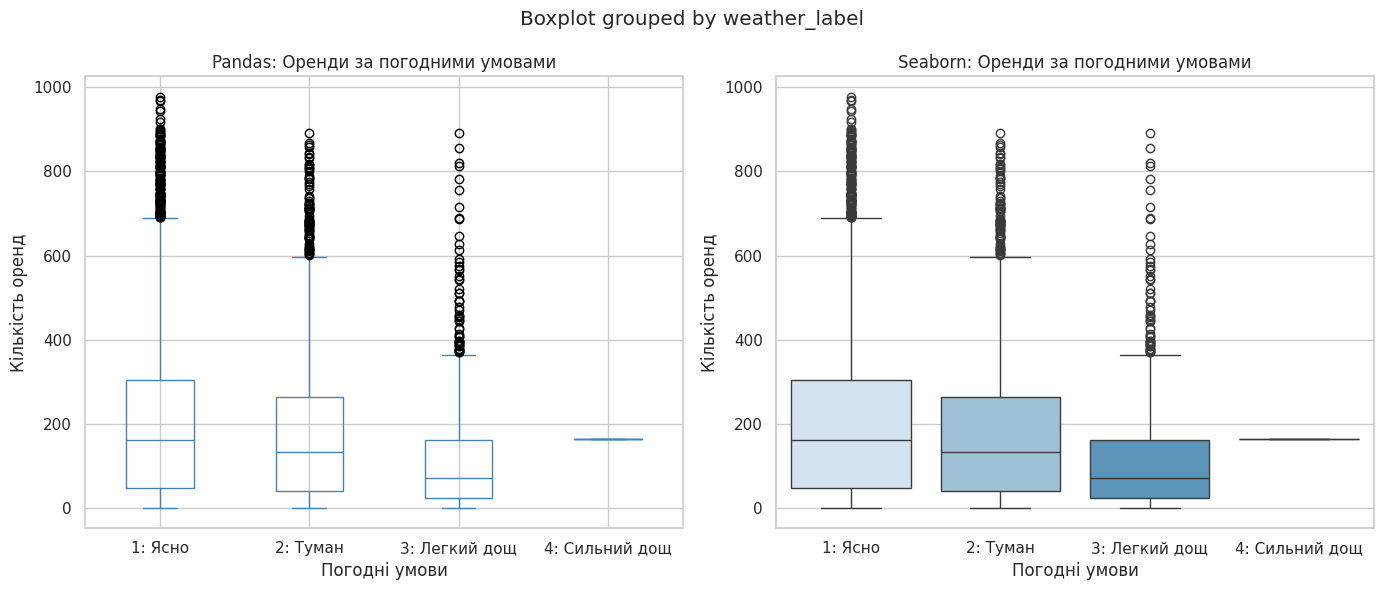

In [15]:
# Підписи погодних умов для осі X
weather_labels = {
    1: '1: Ясно',
    2: '2: Туман',
    3: '3: Легкий дощ',
    4: '4: Сильний дощ'
}
df['weather_label'] = df['weather'].map(weather_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Спосіб 1: Pandas ---
df.boxplot(
    column='count',       # що аналізуємо
    by='weather_label',   # групуємо за погодою
    ax=axes[0],
    color='steelblue'
)
axes[0].set_title('Pandas: Оренди за погодними умовами')
axes[0].set_xlabel('Погодні умови')
axes[0].set_ylabel('Кількість оренд')

# --- Спосіб 2: Seaborn ---
sns.boxplot(
    data=df,
    x='weather_label',    # погода на осі X
    y='count',            # кількість оренд на осі Y
    hue='weather_label',
    ax=axes[1],
    palette='Blues'
)
axes[1].set_title('Seaborn: Оренди за погодними умовами')
axes[1].set_xlabel('Погодні умови')
axes[1].set_ylabel('Кількість оренд')
legend=False

plt.tight_layout()
plt.show();

Pandas будує простий чорно-білий бокс-плот з мінімальним оформленням і автоматично додає загальний заголовок зверху (“Boxplot grouped by weather_label”). Seaborn будує кольоровий графік з кращим стилем — кожна погодна умова має свій відтінок, що робить графік більш читабельним і естетичним.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


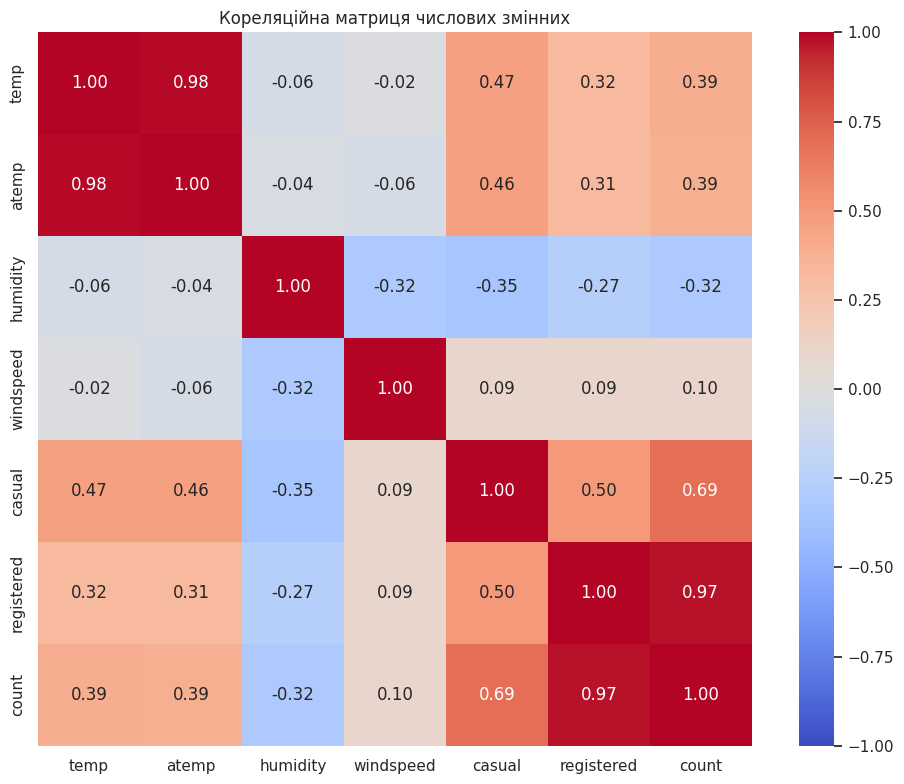

In [17]:
# Вибираємо тільки числові колонки
numeric_cols = ['temp', 'atemp', 'humidity', 'windspeed',
                'casual', 'registered', 'count']

# Рахуємо кореляцію між усіма числовими змінними
corr_matrix = df[numeric_cols].corr()

# Будуємо heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,       # показує числа в кожній клітинці
    fmt='.2f',        # формат числа — 2 знаки після коми
    cmap='coolwarm',  # колір: синій=негативна, червоний=позитивна
    vmin=-1, vmax=1,  # діапазон значень кореляції
    square=True       # квадратні клітинки
)

plt.title('Кореляційна матриця числових змінних')
plt.tight_layout()
plt.show()

1. Які змінні найсильніше корелюють з count?
registered (дуже висока позитивна ~0.97) і casual (~0.69) — зрозуміло, бо count = casual + registered
2. Кореляція між temp та atemp?
Дуже висока позитивна (~0.99) — бо atemp це відчутна температура, яка майже завжди повторює реальну temp
3. Які змінні мають негативну кореляцію?
humidity і windspeed — більша вологість і вітер → менше оренд

## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


/tmp/ipykernel_950/2921549971.py:3: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:steelblue'` for the same effect.

  sns.violinplot(


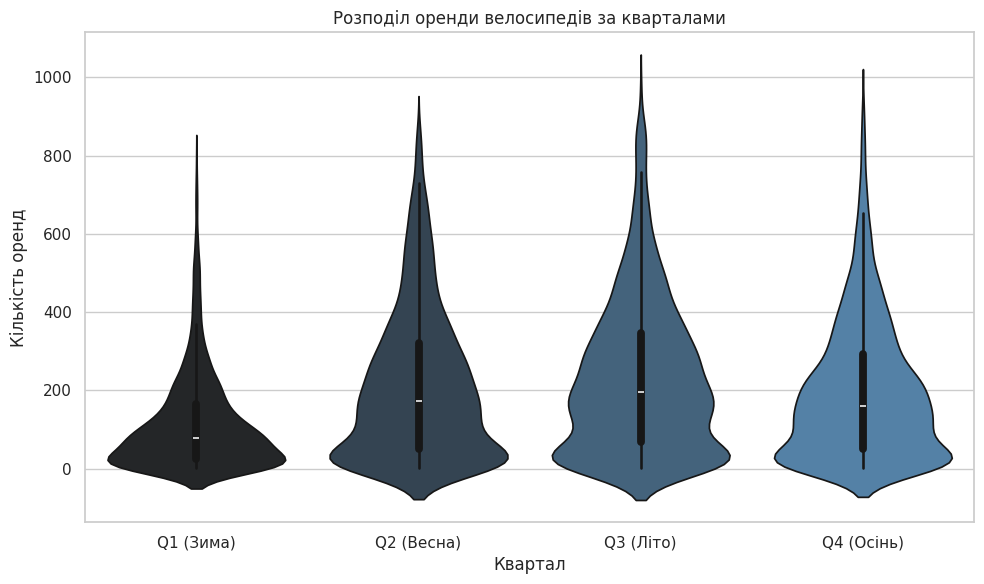

In [20]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x='season',        # квартали на осі X
    y='count',         # кількість оренд на осі Y
    hue='season',      # колір по кварталах
    color='steelblue',
    legend=False
)
plt.xticks(
    ticks=[0, 1, 2, 3],
    labels=['Q1 (Зима)', 'Q2 (Весна)', 'Q3 (Літо)', 'Q4 (Осінь)']
)
plt.title('Розподіл оренди велосипедів за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Кількість оренд')
plt.tight_layout()
plt.show()

1. Що показує “товщина” violin plot?
Товщина = кількість даних у цій точці. Ширше місце → більше записів з таким значенням
2. В якому кварталі найбільша варіабельність?
Q3 (літо) — найширший violin, значення розкидані від низьких до дуже високих
3. Перевага violin plot над box plot?
Box plot показує лише медіану та квартилі. Violin plot показує повний розподіл — видно чи є два піки, чи розподіл рівномірний


## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

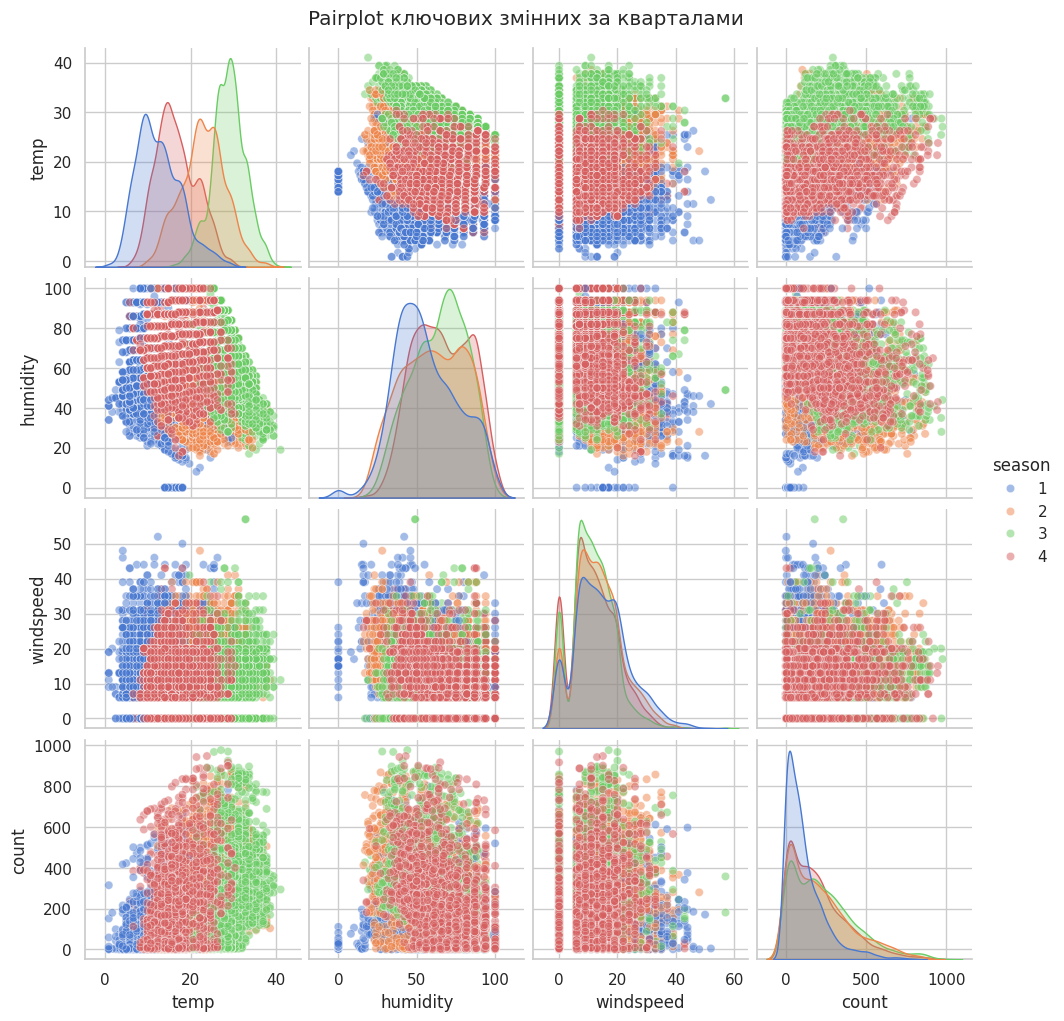

In [21]:
sns.pairplot(
    df[['temp', 'humidity', 'windspeed', 'count', 'season']],
    hue='season',        # розбивка за кварталами
    palette='muted',
    plot_kws={'alpha': 0.5}  # прозорість точок
)

plt.suptitle('Pairplot ключових змінних за кварталами', y=1.02)
plt.show()

1. Найсильніший лінійний звʼязок — між temp і count (більше тепло → більше оренд)
 2. Найбільше відрізняється між кварталами — temp (температура чітко розділяє сезони за кольором)

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

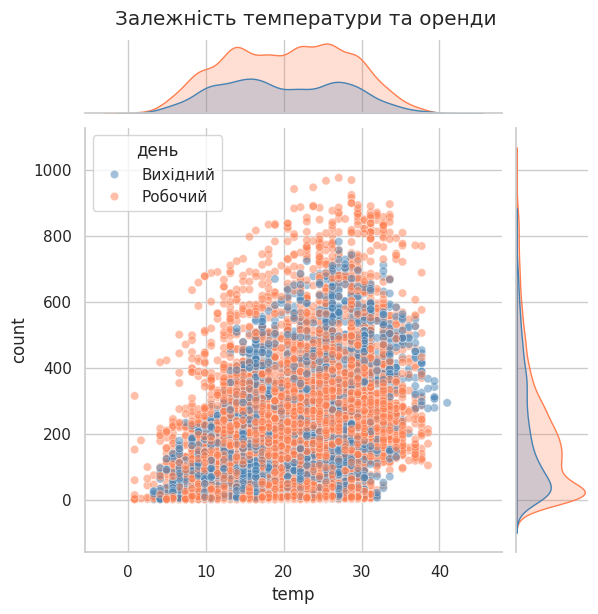

In [23]:
df['день'] = df['workingday'].map({0: 'Вихідний', 1: 'Робочий'})

sns.jointplot(
    data=df,
    x='temp',
    y='count',
    hue='день',
    palette={'Вихідний': 'steelblue', 'Робочий': 'coral'},
    alpha=0.5
)

plt.suptitle('Залежність температури та оренди', y=1.02)
plt.show()

1. Графіки по краях — це розподіли кожної змінної окремо (KDE-криві), показують де зосереджено більшість значень
 2. У робочі дні (workingday=1) оренди більш рівномірні протягом дня, у вихідні — пік зміщується на тепліші години